# **1-Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")

# 2-Load Dataset

In [2]:
df = pd.read_csv('/content/data/diabetes.csv')

# 3-Basic Overview

In [3]:
print("Shape:", df.shape)
df.head()

Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


# 4-Data Types & Missing Values

In [5]:
df.info()

missing = df.isna().sum().sort_values(ascending=False)
missing_percent = (missing / len(df)) * 100
missing_df = pd.DataFrame({"Missing Count": missing, "Missing %": missing_percent})
missing_df[missing_df["Missing Count"] > 0]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,Missing Count,Missing %


# 5-Descriptive Statistics

In [6]:
df.describe(include='all').T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


# 6-Univariate Analysis

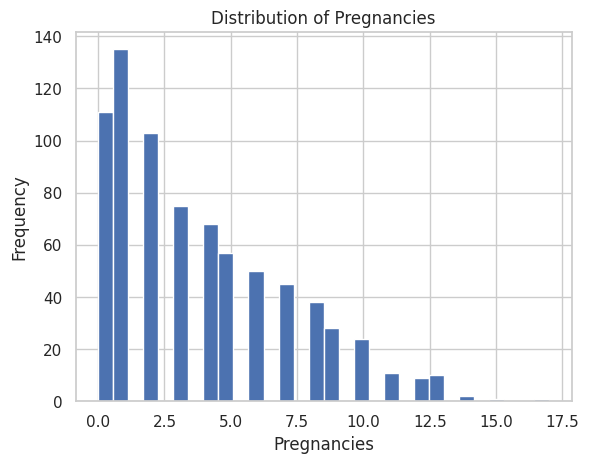

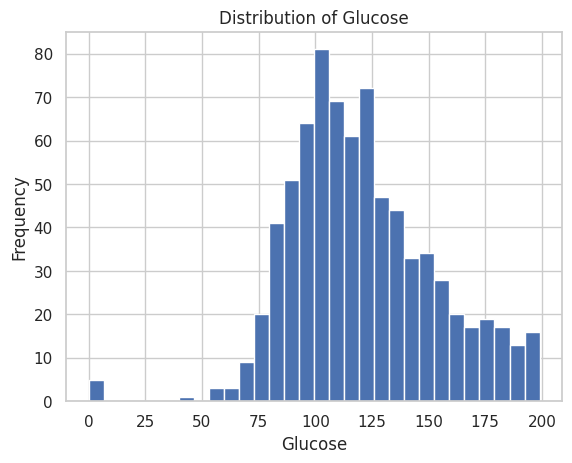

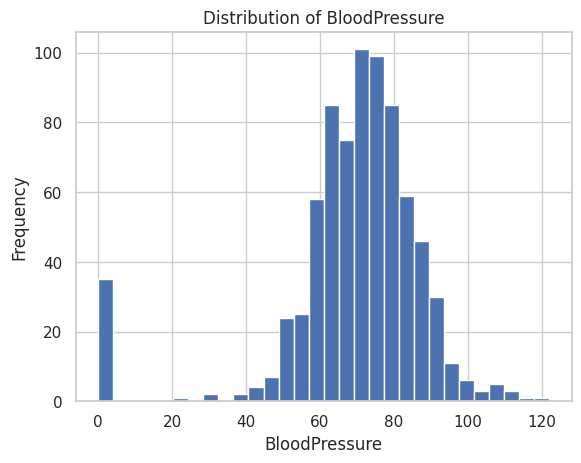

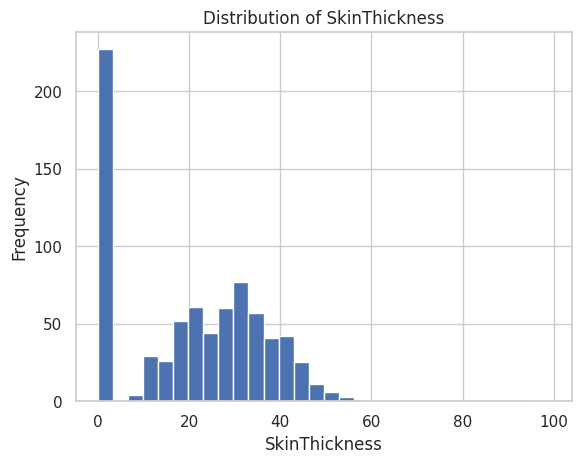

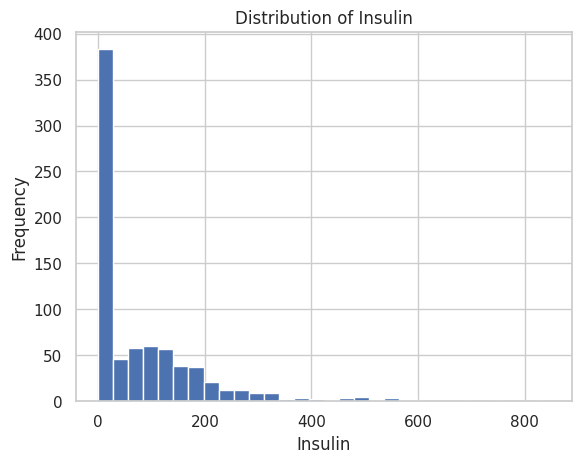

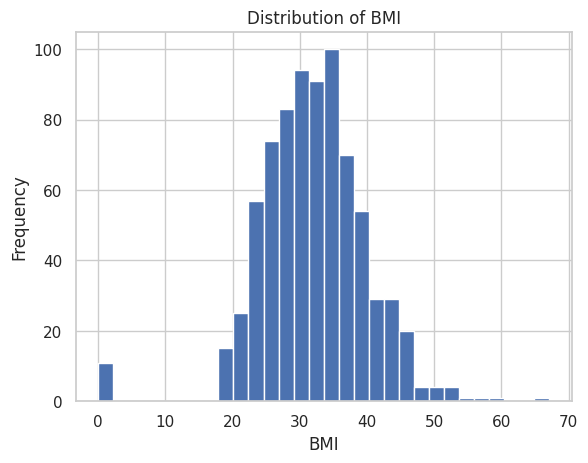

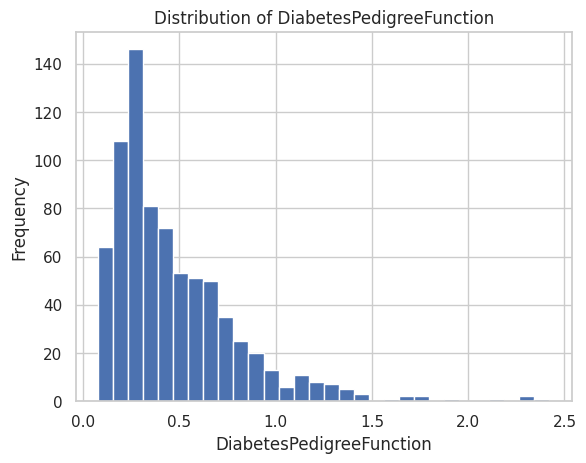

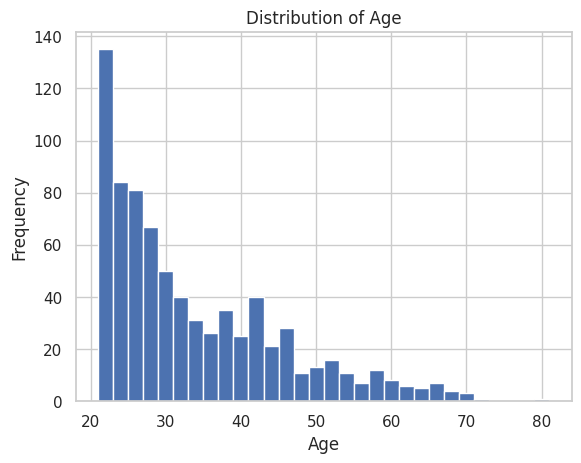

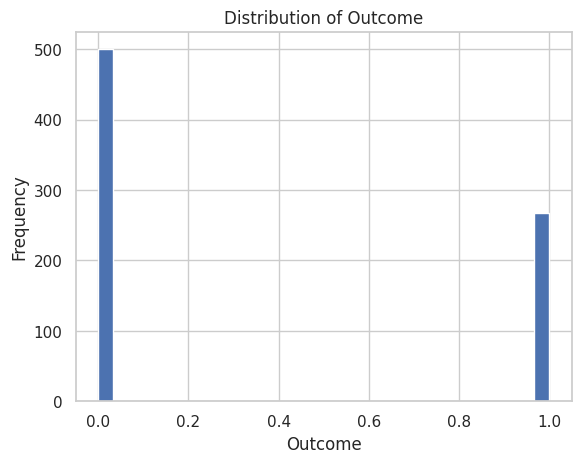

In [8]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    plt.figure()
    df[col].hist(bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

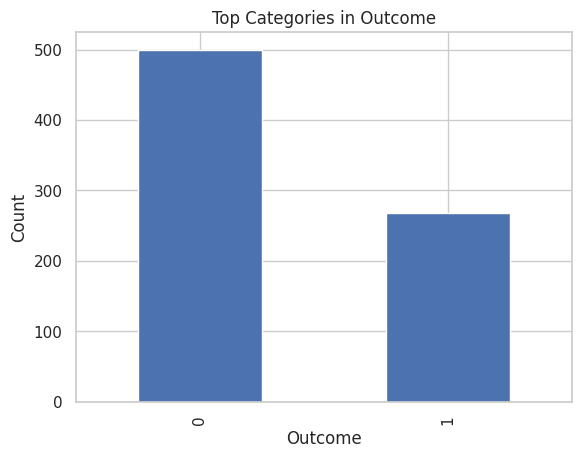

In [17]:
cat_cols = df.select_dtypes(exclude=np.number).columns


for col in cat_cols:
    plt.figure()
df[col].value_counts().head(10).plot(kind='bar')
plt.title(f'Top Categories in {col}')
plt.ylabel('Count')
plt.show()

# 7-Bivariate Analysis

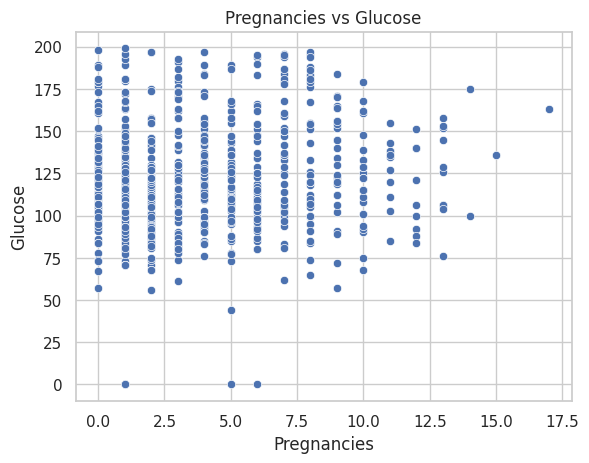

In [18]:
if len(num_cols) >= 2:
    plt.figure()
sns.scatterplot(data=df, x=num_cols[0], y=num_cols[1])
plt.title(f'{num_cols[0]} vs {num_cols[1]}')
plt.show()

# 8-Correlation Analysis

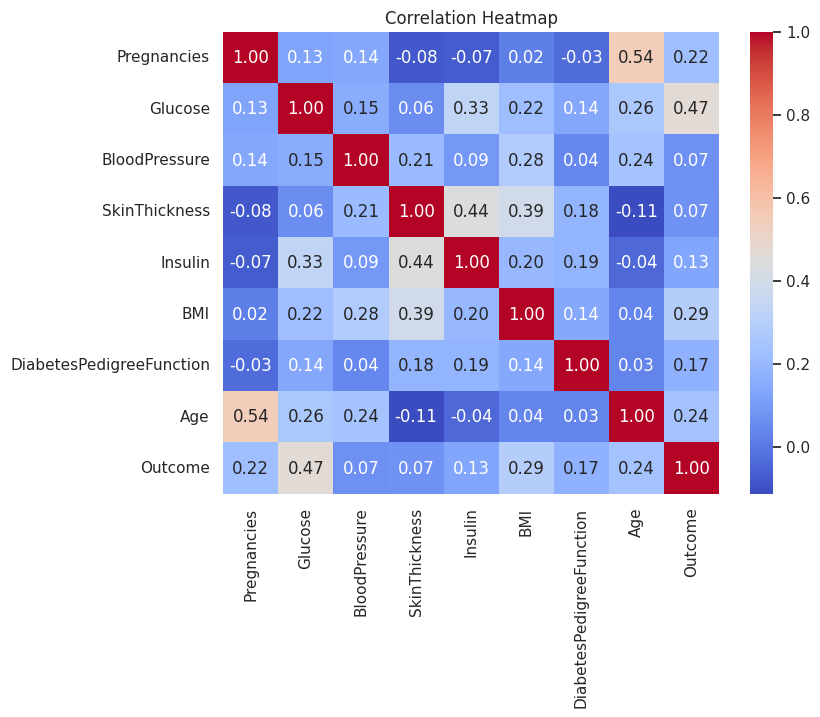

In [32]:
if len(num_cols) > 1:
   corr = df[num_cols].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

# 9-Outlier Detection

In [35]:
outliers_summary = {}
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    outliers_summary[col] = len(outliers)


pd.DataFrame.from_dict(outliers_summary, orient='index', columns=['Outliers Count'])

,Outliers Count
Pregnancies,4
Glucose,5
BloodPressure,45
SkinThickness,1
Insulin,34
BMI,19
DiabetesPedigreeFunction,29
Age,9
Outcome,0
